In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [43]:
df = pd.read_csv("cleaned_data.csv", encoding='latin1')
pd.set_option('display.max_columns', None)

In [44]:
df.head()

,First Name,Date of Birth,Gender,Country,Institution Name,Current/Intended Major,Opportunity Id,Opportunity Name,Opportunity Category,Opportunity Start Date,Opportunity End Date,Learner SignUp DateTime,Apply Date,Entry created at,Status Description,Status Code
0,Faria,1/12/2001,Female,Pakistan,Nwihs,Radiology,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,11/3/2022 18:30,6/29/2024 18:52,6/14/2023 12:30,6/14/2023 12:36,3/11/2024 12:01,Started,1080
1,Poojitha,8/16/2000,Female,India,Saint Louis University,Information Systems,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,11/3/2022 18:30,6/29/2024 18:52,5/1/2023 5:29,5/1/2023 6:08,3/11/2024 12:01,Started,1080
2,Emmanuel,1/27/2002,Male,United States,Illinois Institute Of Technology,Computer Science,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,11/3/2022 18:30,6/29/2024 18:52,4/9/2023 20:35,NaN,3/11/2024 12:01,Started,1080
3,Amrutha Varshini,11/1/1999,Female,United States,Saint Louis University,Information Systems,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,11/3/2022 18:30,6/29/2024 18:52,8/29/2023 5:20,10/9/2023 22:02,3/11/2024 12:01,Team Allocated,1070
4,Vinay Varshith,4/19/2000,Male,United States,Saint Louis University,Computer Science,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,11/3/2022 18:30,6/29/2024 18:52,1/6/2023 15:26,1/6/2023 15:40,3/11/2024 12:01,Started,1080


In [45]:
df.shape

(8558, 16)

# **1. Historical Analysis Category**

# Overall Monthly Signups

In [47]:
# Create clean month-year names on the fly from Learner SignUp DateTime
df['SignUp_Datetime'] = pd.to_datetime(df['Learner SignUp DateTime'], errors='coerce')
df['SignUp Month Name'] = df['SignUp_Datetime'].dt.strftime('%B %Y')
df['SignUp Month Period'] = df['SignUp_Datetime'].dt.to_period('M')

print("--- Overall Application Trends (Signups by Month) ---")
# Sort chronologically by time period, then map to clean string format
monthly_counts = df.groupby(['SignUp Month Period', 'SignUp Month Name']).size().reset_index(name='count')

for _, row in monthly_counts.iterrows():
    print(f"  - {row['SignUp Month Name']}: {int(row['count'])} signups")

--- Overall Application Trends (Signups by Month) ---
  - January 2023: 229 signups
  - February 2023: 86 signups
  - March 2023: 183 signups
  - April 2023: 278 signups
  - May 2023: 400 signups
  - June 2023: 743 signups
  - July 2023: 696 signups
  - August 2023: 1110 signups
  - September 2023: 649 signups
  - October 2023: 407 signups
  - November 2023: 201 signups
  - December 2023: 642 signups
  - January 2024: 1509 signups
  - February 2024: 1007 signups
  - March 2024: 123 signups


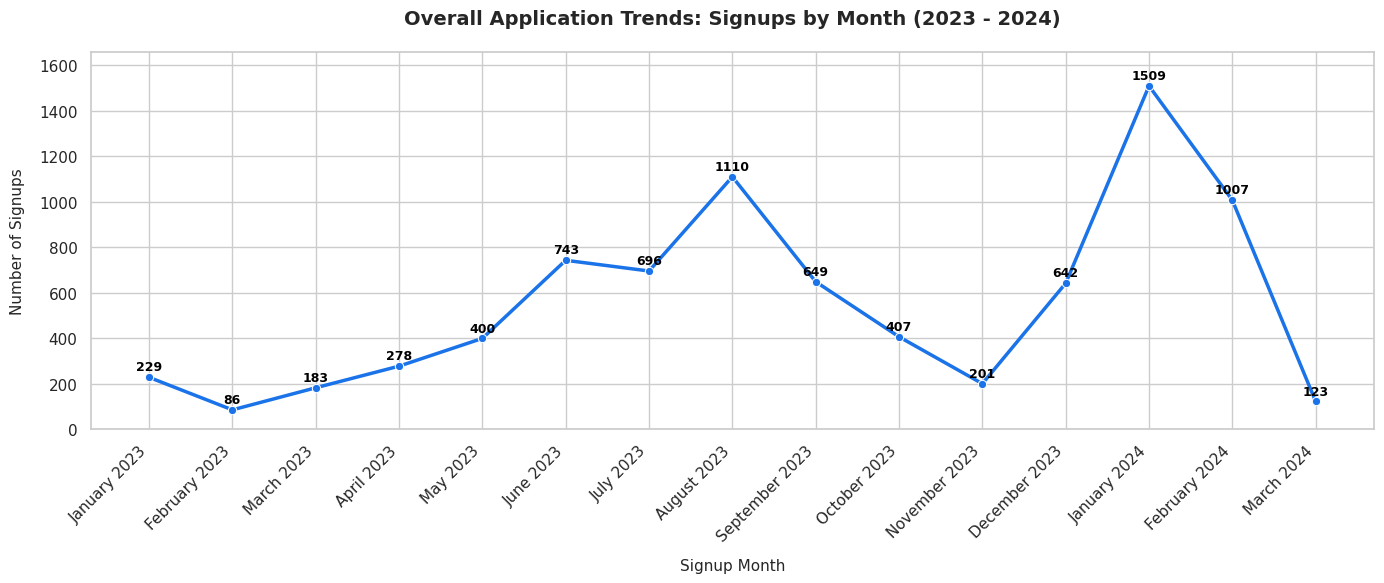

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the month column is sorted chronologically for the chart
monthly_counts_sorted = monthly_counts.sort_values('SignUp Month Period')

# Set up the plotting style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# Create the trend line chart
sns.lineplot(
    data=monthly_counts_sorted,
    x='SignUp Month Name',
    y='count',
    marker='o',
    linewidth=2.5,
    color='#1a73e8'
)

# Add data labels on top of each marker point
for _, row in monthly_counts_sorted.iterrows():
    plt.text(
        x=row['SignUp Month Name'],
        y=row['count'] + 30, # Offsets the text slightly above the marker
        s=f"{int(row['count'])}",
        color='black',
        fontsize=9,
        ha='center',
        fontweight='semibold'
    )

# Customize titles and labels to match corporate deliverable standards
plt.title('Overall Application Trends: Signups by Month (2023 - 2024)', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Signup Month', fontsize=11, labelpad=10)
plt.ylabel('Number of Signups', fontsize=11, labelpad=10)

# Clean up axes presentation
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(monthly_counts_sorted['count']) + 150)
plt.tight_layout()

# Display plot
plt.show()

### Interpretation

The monthly signup trend shows how many learners registered each month.

* **January to May 2023:** Signups gradually increased from **229** in January to **400** in May, showing growing interest.
* **June to August 2023:** There was a strong increase, with **743** signups in June, **696** in July, and a peak of **1,110** in August. This was the busiest period of 2023.
* **September to November 2023:** Signups declined from **649** in September to **201** in November, indicating lower application activity.
* **December 2023:** Signups recovered to **642**, suggesting renewed interest at the end of the year.
* **January 2024:** Applications reached the **highest level** with **1,509** signups, showing a very strong start to the new year.
* **February 2024:** Signups remained high at **1,007**, although lower than January.
* **March 2024:** Only **123** signups are shown. This is likely because the data for March is **incomplete** (only part of the month may be included), so it should not be compared directly with the other months.

### Summary

Overall, learner signups showed an upward trend over the period. Applications increased steadily during 2023, peaked in **August 2023**, declined in the following months, and then rose sharply again in **January 2024**, which recorded the highest number of signups. The low count for **March 2024** is likely due to incomplete data rather than a true decrease in applications.


# Yearly Totals & Month-over-Month Growth

In [33]:
print("--- Growth Patterns: Total Signups by Year ---")
df['SignUp Year'] = df['SignUp_Datetime'].dt.year
yearly_counts = df['SignUp Year'].value_counts().sort_index()

for year, count in yearly_counts.items():
    if pd.notna(year):
        print(f"  - Year {int(year)}: {int(count)} total signups")

# Month-over-Month growth analysis
print("\n--- Month-over-Month Change in Signups ---")
monthly_trend = df.groupby('SignUp Month Period').size()
monthly_growth = monthly_trend.pct_change() * 100

for i in range(1, len(monthly_trend)):
    month_str = monthly_trend.index[i].strftime('%B %Y')
    print(f"  - Progress to {month_str}: {monthly_growth.iloc[i]:+.2f}% change")

--- Growth Patterns: Total Signups by Year ---
  - Year 2023: 5624 total signups
  - Year 2024: 2639 total signups

--- Month-over-Month Change in Signups ---
  - Progress to February 2023: -62.45% change
  - Progress to March 2023: +112.79% change
  - Progress to April 2023: +51.91% change
  - Progress to May 2023: +43.88% change
  - Progress to June 2023: +85.75% change
  - Progress to July 2023: -6.33% change
  - Progress to August 2023: +59.48% change
  - Progress to September 2023: -41.53% change
  - Progress to October 2023: -37.29% change
  - Progress to November 2023: -50.61% change
  - Progress to December 2023: +219.40% change
  - Progress to January 2024: +135.05% change
  - Progress to February 2024: -33.27% change
  - Progress to March 2024: -87.79% change


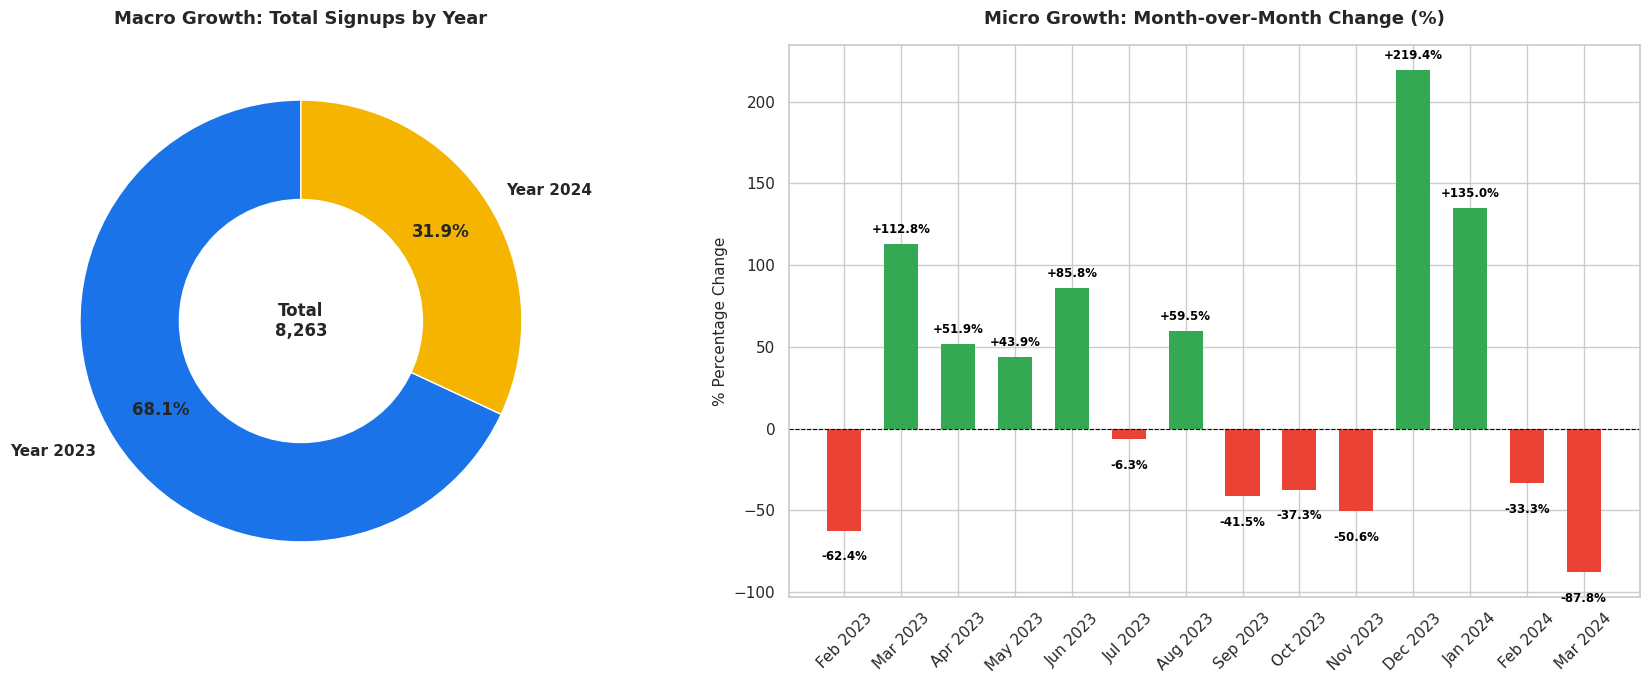

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.set_theme(style="whitegrid")

# ----------------------------------------------------
# PLOT 1: Yearly Signup Distribution (Donut Chart)
# ----------------------------------------------------
years = [f"Year {int(y)}" for y in yearly_counts.index if pd.notna(y)]
counts = [int(c) for y, c in yearly_counts.items() if pd.notna(y)]
colors = ['#1a73e8', '#f4b400']

# Plot pie chart
wedges, texts, autotexts = axes[0].pie(
    counts,
    labels=years,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops=dict(fontweight='semibold'),
    pctdistance=0.75
)

# Draw a white circle in the center to turn it into a donut chart
centre_circle = plt.Circle((0,0), 0.55, fc='white')
axes[0].add_artist(centre_circle)

# Add center text with total signups
total_signups = sum(counts)
axes[0].text(0, 0, f'Total\n{total_signups:,}', ha='center', va='center', fontsize=12, fontweight='bold')
axes[0].set_title('Macro Growth: Total Signups by Year', fontsize=13, fontweight='bold', pad=15)

# ----------------------------------------------------
# PLOT 2: Month-over-Month % Change (Diverging Bar Chart)
# ----------------------------------------------------
# Prepare MoM data excluding the first element (NaN)
mom_months = [monthly_trend.index[i].strftime('%b %Y') for i in range(1, len(monthly_trend))]
mom_values = [monthly_growth.iloc[i] for i in range(1, len(monthly_trend))]

# Assign colors based on positive vs negative growth
bar_colors = ['#34a853' if x >= 0 else '#ea4335' for x in mom_values]

# Plot horizontal or vertical bar chart (vertical looks cleaner here)
bars = axes[1].bar(mom_months, mom_values, color=bar_colors, edgecolor='none', width=0.6)

# Add data labels on top/bottom of each bar
for bar in bars:
    height = bar.get_height()
    va_dir = 'bottom' if height >= 0 else 'top'
    offset = 5 if height >= 0 else -12
    axes[1].text(
        bar.get_x() + bar.get_width()/2.,
        height + offset,
        f"{height:+.1f}%",
        ha='center',
        va=va_dir,
        fontsize=8.5,
        fontweight='semibold',
        color='black'
    )

# Formatting the MoM chart
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--') # Baseline at 0%
axes[1].set_title('Micro Growth: Month-over-Month Change (%)', fontsize=13, fontweight='bold', pad=15)
axes[1].set_ylabel('% Percentage Change', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)

# Clean adjustments
plt.tight_layout()
plt.show()

### Interpretation

#### **Growth Patterns: Total Signups by Year**

* **2023:** A total of **5,624** learners signed up.
* **2024:** A total of **2,639** learners signed up **(up to March only)**, so this is not a full-year comparison.

#### **Month-over-Month Change in Signups**

* Signups **dropped sharply** in **February 2023 (-62.45%)** compared to January.
* From **March to June 2023**, signups increased consistently, with the biggest rise in **June (+85.75%)**.
* There was a **small decline** in **July (-6.33%)**, followed by another strong increase in **August (+59.48%)**.
* From **September to November 2023**, signups decreased each month, showing a slowdown in applications.
* **December 2023 (+219.40%)** recorded a significant recovery in signups.
* **January 2024 (+135.05%)** showed another strong increase, reaching the highest signup level.
* Signups declined in **February 2024 (-33.27%)** and dropped sharply in **March 2024 (-87.79%)**, likely because the March data is incomplete.

### Summary

Overall, learner signups fluctuated throughout the period, with both increases and decreases across different months. The strongest growth occurred in **December 2023** and **January 2024**, while the biggest declines were seen in **February 2023** and **March 2024**. Since the 2024 data only includes the first three months, it should not be directly compared with the full-year 2023 totals.


# **2. Opportunity Category Analysis**

# Share & Unique Counts per Category

In [34]:
# Total Signups by Category
print("--- Total Signups per Category ---")
print(df['Opportunity Category'].value_counts())

# Percentage Distribution
print("\n--- Percentage Share per Category (%) ---")
print((df['Opportunity Category'].value_counts(normalize=True) * 100).round(2))

# Unique Offerings per Category
print("\n--- Unique Opportunities per Category ---")
print(df.groupby('Opportunity Category')['Opportunity Id'].nunique())

--- Total Signups per Category ---
Opportunity Category
Internship     5421
Course         2037
Event           545
Competition     425
Engagement      130
Name: count, dtype: int64

--- Percentage Share per Category (%) ---
Opportunity Category
Internship     63.34
Course         23.80
Event           6.37
Competition     4.97
Engagement      1.52
Name: proportion, dtype: float64

--- Unique Opportunities per Category ---
Opportunity Category
Competition    5
Course         4
Engagement     2
Event          3
Internship     9
Name: Opportunity Id, dtype: int64


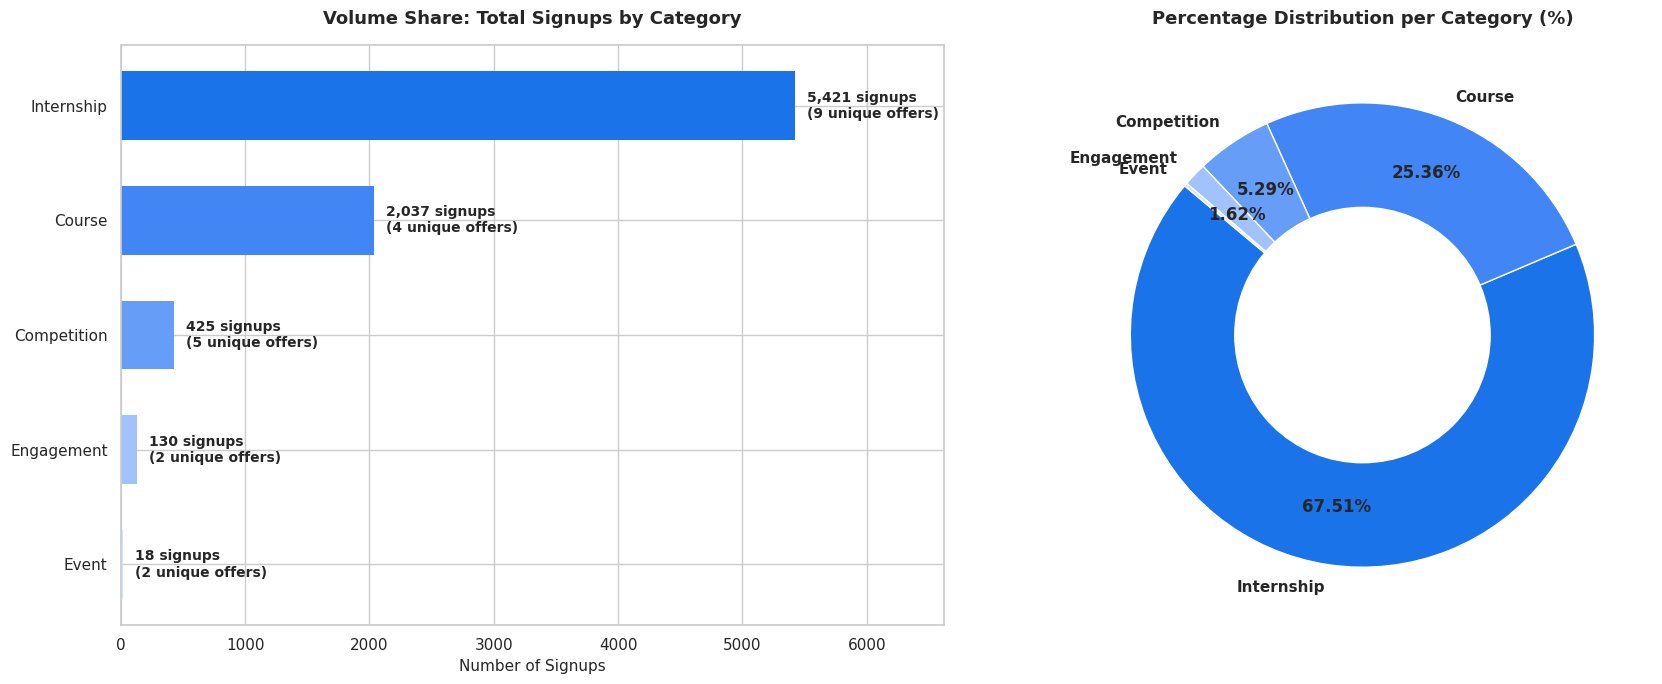

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extracting data from your analysis results
categories = ['Internship', 'Course', 'Competition', 'Engagement', 'Event']
signup_counts = [5421, 2037, 425, 130, 18]
percentage_share = [67.50, 25.36, 5.29, 1.62, 0.22]
unique_counts = [9, 4, 5, 2, 2]

# Set up figure
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.set_theme(style="whitegrid")

# ----------------------------------------------------
# PLOT 1: Raw Volume Distribution (Horizontal Bars)
# ----------------------------------------------------
# Using a custom color palette that emphasizes dominant categories
palette = ['#1a73e8', '#4285f4', '#669df6', '#a1c2fa', '#d2e3fc']

bars = axes[0].barh(categories, signup_counts, color=palette, edgecolor='none', height=0.6)
axes[0].invert_yaxis()  # Put the top category (Internship) at the top

# Add value labels to the end of each bar
for bar, unique in zip(bars, unique_counts):
    width = bar.get_width()
    axes[0].text(
        width + 100,
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,} signups\n({unique} unique offers)",
        va='center',
        ha='left',
        fontsize=10,
        fontweight='semibold'
    )

axes[0].set_title('Volume Share: Total Signups by Category', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Number of Signups', fontsize=11)
axes[0].set_xlim(0, max(signup_counts) + 1200)

# ----------------------------------------------------
# PLOT 2: Percentage Share per Category (Donut Chart)
# ----------------------------------------------------
# Combine small categories for clear pie presentation if needed, or plot directly
axes[1].pie(
    percentage_share,
    labels=categories,
    autopct=lambda p: f'{p:.2f}%' if p > 1 else '', # Hide text for tiny slices to avoid overlap
    startangle=140,
    colors=palette,
    textprops=dict(fontweight='semibold'),
    pctdistance=0.75
)

# Turn it into a beautiful donut chart
centre_circle = plt.Circle((0,0), 0.55, fc='white')
axes[1].add_artist(centre_circle)

axes[1].set_title('Percentage Distribution per Category (%)', fontsize=13, fontweight='bold', pad=15)

# Tight layout adjustments
plt.tight_layout()
plt.show()

### Interpretation

* **Internships** received the **highest number of signups (5,421)**, making them the most popular opportunity type.
* **Courses** were the second most popular with **2,037 signups**.
* **Events (545)** and **Competitions (425)** attracted a moderate number of learners.
* **Engagement** opportunities had the **fewest signups (130)**, showing the lowest learner interest.

#### Percentage Distribution

* **Internships** accounted for **63.34%** of all signups, meaning nearly **2 out of every 3 learners** applied for an internship.
* **Courses** made up **23.80%** of total signups, representing almost **1 in 4 learners**.
* **Events (6.37%)**, **Competitions (4.97%)**, and **Engagement (1.52%)** contributed only a small share of total signups.

#### Unique Opportunities per Category

* **Internships** offered the **largest variety**, with **9 unique opportunities**.
* **Competitions** had **5 unique opportunities**.
* **Courses** included **4 unique opportunities**.
* **Events** had **3 unique opportunities**.
* **Engagement** offered the **fewest options**, with only **2 unique opportunities**.

### Summary

Overall, **internships were by far the most popular opportunity category**, attracting the majority of learner signups and offering the largest number of opportunities. **Courses** were the second most preferred category, while **events, competitions, and engagement activities** received comparatively lower interest. This suggests that learners were primarily interested in opportunities that provide practical experience and skill development.


# Participation & Conversion Rates

In [35]:
df['Participated'] = df['Status Description'].isin(['Started', 'Team Allocated', 'Rewards Award'])
# Participation and status conversion rates by category
print("--- Overall Participation Rate by Category (%) ---")
print((df.groupby('Opportunity Category')['Participated'].mean() * 100).round(2))

# Broad status distribution to see clear leaders vs heavy dropouts
status_summary = pd.crosstab(df['Opportunity Category'], df['Status Description'])
print("\n--- Raw Volume of Learner Statuses per Category ---")
print(status_summary)

--- Overall Participation Rate by Category (%) ---
Opportunity Category
Competition    84.24
Course         93.18
Engagement     96.92
Event          96.33
Internship     21.49
Name: Participated, dtype: float64

--- Raw Volume of Learner Statuses per Category ---
Status Description    Applied  Dropped Out  Rejected  Rewards Award  Started  \
Opportunity Category                                                           
Competition                62            4         0              0        0   
Course                      6            0         0             17      767   
Engagement                  4            0         0              0        0   
Event                      18            0         0             12        0   
Internship                 15          613      3569              0        0   

Status Description    Team Allocated  Waitlisted  Withdraw  
Opportunity Category                                        
Competition                      358           0    

# Status Funnel Breakdown

In [36]:
# Calculate the percentage funnel breakdown
funnel_pct = pd.crosstab(df['Opportunity Category'], df['Status Description'], normalize='index') * 100

print("--- Clean and Readable Status Funnel (%) ---\n")

# Loop through each category to print its funnel individually
for category in funnel_pct.index:
    print(f"Category: {category}")

    # Sort the statuses from highest percentage to lowest for maximum clarity
    sorted_statuses = funnel_pct.loc[category].sort_values(ascending=False)

    # Only print statuses where students actually exist (greater than 0%)
    for status, pct in sorted_statuses.items():
        if pct > 0:
            print(f"  - {status}: {pct:.2f}%")
    print()  # Adds an empty line between categories

--- Clean and Readable Status Funnel (%) ---

Category: Competition
  - Team Allocated: 84.24%
  - Applied: 14.59%
  - Dropped Out: 0.94%
  - Withdraw: 0.24%

Category: Course
  - Team Allocated: 54.69%
  - Started: 37.65%
  - Waitlisted: 5.35%
  - Withdraw: 1.18%
  - Rewards Award: 0.83%
  - Applied: 0.29%

Category: Engagement
  - Team Allocated: 96.92%
  - Applied: 3.08%

Category: Event
  - Team Allocated: 94.13%
  - Applied: 3.30%
  - Rewards Award: 2.20%
  - Withdraw: 0.37%

Category: Internship
  - Rejected: 65.84%
  - Team Allocated: 21.49%
  - Dropped Out: 11.31%
  - Withdraw: 1.09%
  - Applied: 0.28%



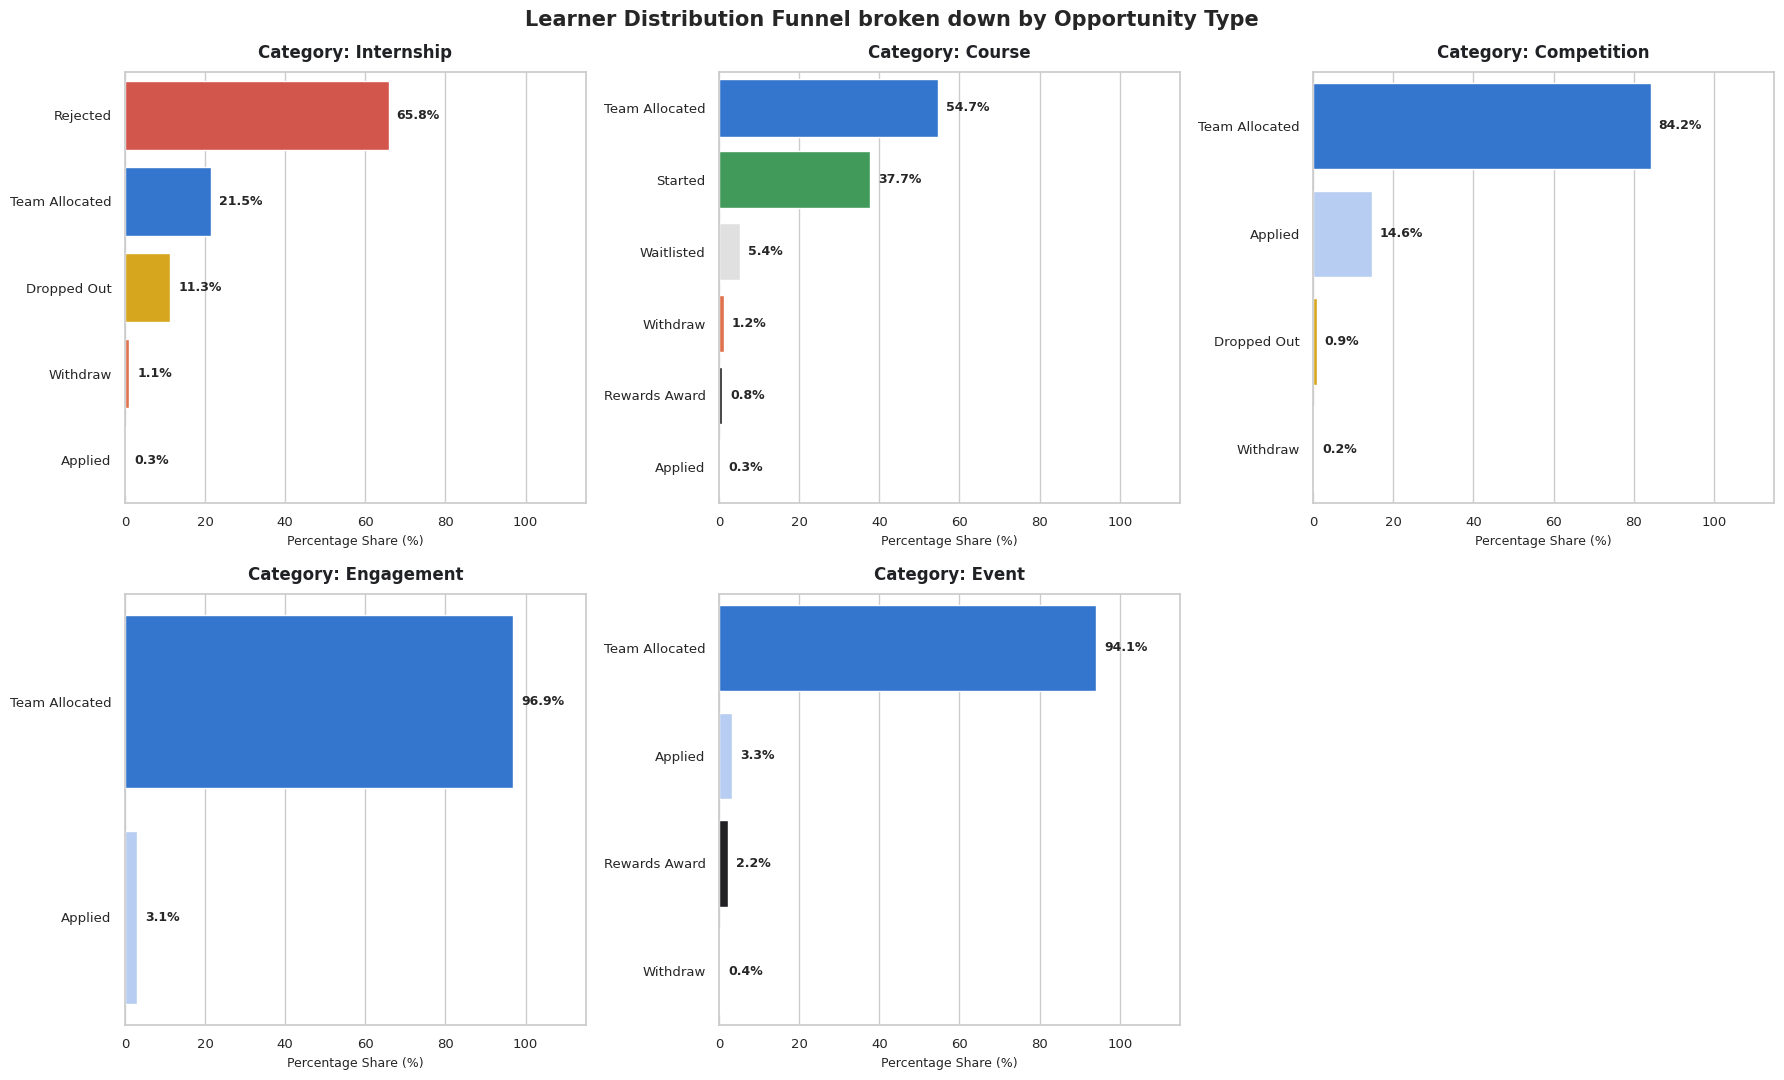

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the categories are ordered by overall popularity
category_order = ['Internship', 'Course', 'Competition', 'Engagement', 'Event']

# Set up a grid of subplots (2 rows, 3 columns to neatly fit all 5 categories)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()  # Flatten the 2D grid matrix into a 1D array for easy looping

# Define matching status colors to keep visual consistency
status_colors = {
    'Applied': '#aecbfa', 'Waitlisted': '#e0e0e0', 'Team Allocated': '#1a73e8',
    'Started': '#34a853', 'Rewards Award': '#202124', 'Dropped Out': '#f4b400',
    'Withdraw': '#f86734', 'Rejected': '#ea4335'
}

# Loop through each category and build an individual simplified bar chart
for i, cat in enumerate(category_order):
    ax = axes[i]

    # Extract data for this category, sort descending, and filter out 0% values
    cat_series = funnel_pct.loc[cat].sort_values(ascending=False)
    cat_series = cat_series[cat_series > 0]

    # Generate the bar plot
    sns.barplot(
        x=cat_series.values,
        y=cat_series.index,
        ax=ax,
        palette=[status_colors.get(idx, '#cccccc') for idx in cat_series.index],
        hue=cat_series.index,
        legend=False
    )

    # Add data value labels on top of each bar
    for patch in ax.patches:
        width = patch.get_width()
        ax.text(
            width + 2,
            patch.get_y() + patch.get_height()/2,
            f'{width:.1f}%',
            va='center',
            ha='left',
            fontsize=9,
            fontweight='bold'
        )

    # Formatting each individual subplot card
    ax.set_title(f'Category: {cat}', fontsize=12, fontweight='bold', color='#202124', pad=10)
    ax.set_xlim(0, 115) # Leave room on the right for the percentage labels
    ax.set_xlabel('Percentage Share (%)', fontsize=9)
    ax.set_ylabel('', fontsize=9)
    ax.tick_params(labelsize=9.5)

# Hide the 6th empty subplot grid cell since we only have 5 categories
fig.delaxes(axes[5])

# Title and global layout styling
plt.suptitle('Learner Distribution Funnel broken down by Opportunity Type', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

### Interpretation

#### Competition

* **84.24%** of learners reached the **Team Allocated** stage.
* **14.59%** remained in the **Applied** stage.
* Less than **1%** dropped out or withdrew, showing good learner retention.

#### Course

* More than half (**54.69%**) reached **Team Allocated**.
* **37.65%** had **Started** the course.
* A small number were **Waitlisted (5.35%)**, while very few withdrew or received rewards.

#### Engagement

* Almost all learners (**96.92%**) reached **Team Allocated**.
* Only **3.08%** remained in the **Applied** stage, indicating excellent participation.

#### Event

* **94.13%** of learners reached **Team Allocated**.
* **2.20%** received **Rewards Award**, while only a few remained applied or withdrew.

#### Internship

* **65.84%** of applicants were **Rejected**, making it the largest status.
* Only **21.49%** reached **Team Allocated**.
* **11.31%** dropped out, while very few remained applied or withdrew.

### Summary

Overall, **engagements, events, courses, and competitions** had strong learner progression, with most participants reaching the **Team Allocated** stage. **Internships followed a very different pattern**, where most applicants were **rejected**, and only about one-fifth progressed. This suggests that internships are much more competitive and selective than the other opportunity categories.


# **3. Additional Analysis**

# Demographics Sub-Category

In [37]:
df['Age at SignUp (years)'] = (pd.to_datetime(df['Learner SignUp DateTime']) - pd.to_datetime(df['Date of Birth'])).dt.days / 365.25
# Gender breakdown percentages per category
print("--- Gender Distribution per Category (%) ---")
gender_pct = pd.crosstab(df['Opportunity Category'], df['Gender'], normalize='index') * 100
print(gender_pct.round(2))

# Age profile (Average and Median) per category
print("\n--- Age Profile per Category ---")
print(df.groupby('Opportunity Category')['Age at SignUp (years)'].agg(['mean', 'median']).round(2))

--- Gender Distribution per Category (%) ---
Gender                Don't want to specify  Female   Male  Other
Opportunity Category                                             
Competition                            0.00   36.94  63.06   0.00
Course                                 0.59   43.84  55.52   0.05
Engagement                             0.00   36.15  63.85   0.00
Event                                  0.18   39.63  60.18   0.00
Internship                             0.04   40.75  59.18   0.04

--- Age Profile per Category ---
                       mean  median
Opportunity Category               
Competition           23.27   22.81
Course                23.57   22.96
Engagement            23.96   22.93
Event                 24.08   22.97
Internship            24.15   23.39


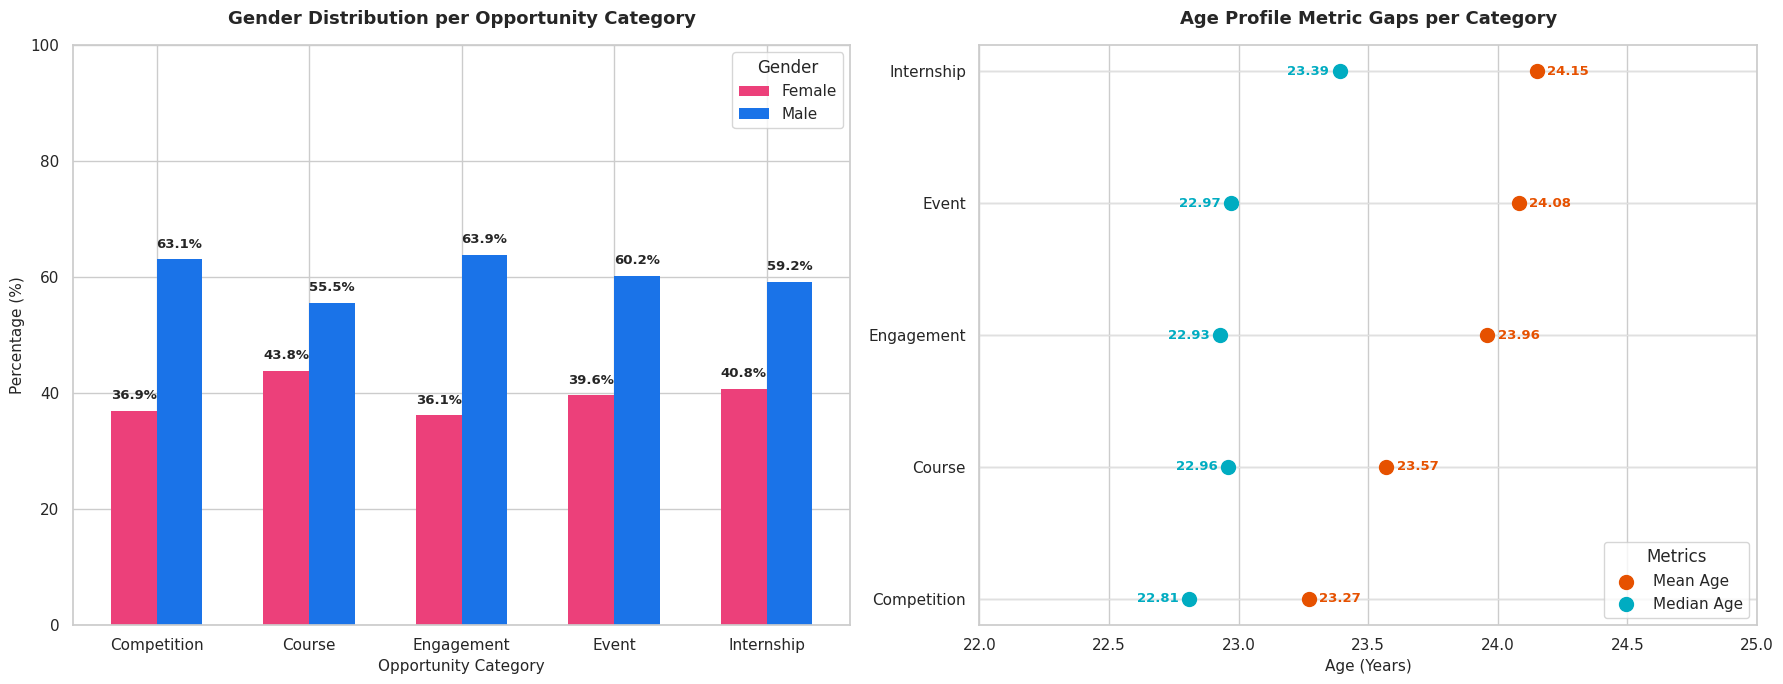

In [54]:

# ----------------------------------------------------
# Data Preparation from your analysis outputs
# ----------------------------------------------------
categories = ['Competition', 'Course', 'Engagement', 'Event', 'Internship']

# Gender data (Focusing on Female vs Male for clean side-by-side comparison)
gender_data = pd.DataFrame({
    'Female': [36.94, 43.84, 36.15, 39.63, 40.75],
    'Male': [63.06, 55.52, 63.85, 60.18, 59.18]
}, index=categories)

# Age profile data
age_data = pd.DataFrame({
    'Mean Age': [23.27, 23.57, 23.96, 24.08, 24.15],
    'Median Age': [22.81, 22.96, 22.93, 22.97, 23.39]
}, index=categories)

# Initialize setup
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.set_theme(style="whitegrid")

# ----------------------------------------------------
# PLOT 1: Gender Distribution (Grouped Bar Chart)
# ----------------------------------------------------
gender_data.plot(kind='bar', ax=axes[0], color=['#ec407a', '#1a73e8'], width=0.6, edgecolor='none')

# Add data percentage labels on top of the bars
for patch in axes[0].patches:
    height = patch.get_height()
    if height > 0:
        axes[0].text(
            patch.get_x() + patch.get_width()/2.,
            height + 1.5,
            f"{height:.1f}%",
            ha='center', va='bottom', fontsize=9.5, fontweight='semibold'
        )

axes[0].set_title('Gender Distribution per Opportunity Category', fontsize=13, fontweight='bold', pad=15)
axes[0].set_ylabel('Percentage (%)', fontsize=11)
axes[0].set_xlabel('Opportunity Category', fontsize=11)
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Gender', loc='upper right')

# ----------------------------------------------------
# PLOT 2: Age Profiles (Clean Dot Plot)
# ----------------------------------------------------
# Plot mean markers
axes[1].scatter(age_data['Mean Age'], age_data.index, color='#e65100', s=100, label='Mean Age', zorder=3)
# Plot median markers
axes[1].scatter(age_data['Median Age'], age_data.index, color='#00acc1', s=100, label='Median Age', zorder=3)

# Draw horizontal placeholder tracking lines connecting the markers to the axis
for cat in categories:
    axes[1].axhline(y=cat, color='#e0e0e0', linestyle='-', linewidth=1, zorder=1)

# Add explicit numeric labels next to the dots
for cat in categories:
    axes[1].text(age_data.loc[cat, 'Mean Age'] + 0.04, cat, f"{age_data.loc[cat, 'Mean Age']:.2f}", va='center', ha='left', color='#e65100', fontsize=9.5, fontweight='bold')
    axes[1].text(age_data.loc[cat, 'Median Age'] - 0.04, cat, f"{age_data.loc[cat, 'Median Age']:.2f}", va='center', ha='right', color='#00acc1', fontsize=9.5, fontweight='bold')

axes[1].set_title('Age Profile Metric Gaps per Category', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Age (Years)', fontsize=11)
axes[1].set_xlim(22.0, 25.0) # Zooming in on the micro variance tightly
axes[1].legend(title='Metrics', loc='lower right')

# Global Layout Polishing
plt.tight_layout()
plt.show()

### Interpretation

#### Gender Distribution by Category

* **Male learners** made up the majority of signups across all opportunity categories.
* **Female participation** ranged from about **37% to 44%**, with the **highest representation in Courses (43.84%)**.
* **Competitions (63.06% male)** and **Engagement (63.85% male)** had the highest proportion of male learners.
* Very few learners selected **"Other"** or **"Don't want to specify"** as their gender.

#### Age Profile by Category

* The **average age** of learners across all categories was between **23 and 24 years**.
* The **median age** was around **23 years** for every category, showing that most learners were in a similar age group.
* **Internship applicants** had the highest average age (**24.15 years**), while **Competition participants** were slightly younger on average (**23.27 years**).

### Summary

Overall, the learner population was **mostly male**, although female participation was also substantial, especially in **courses**. The age profile was very consistent across all opportunity categories, with most learners being **around 23–24 years old**, indicating that these opportunities mainly attracted young adults.


In [38]:
# Show top 3 participating countries for each category
print("--- Top 3 Countries per Opportunity Category ---")
for category in df['Opportunity Category'].unique():
    print(f"\nCategory: {category}")
    top_countries = df[df['Opportunity Category'] == category]['Country'].value_counts().head(3)
    print(top_countries)

--- Top 3 Countries per Opportunity Category ---

Category: Course
Country
India            684
United States    668
Nigeria          240
Name: count, dtype: int64

Category: Competition
Country
United States    225
India            147
Nigeria           18
Name: count, dtype: int64

Category: Internship
Country
United States    2800
India            1754
Nigeria           437
Name: count, dtype: int64

Category: Event
Country
United States    220
India            187
Nigeria           65
Name: count, dtype: int64

Category: Engagement
Country
India            64
United States    63
Pakistan          1
Name: count, dtype: int64


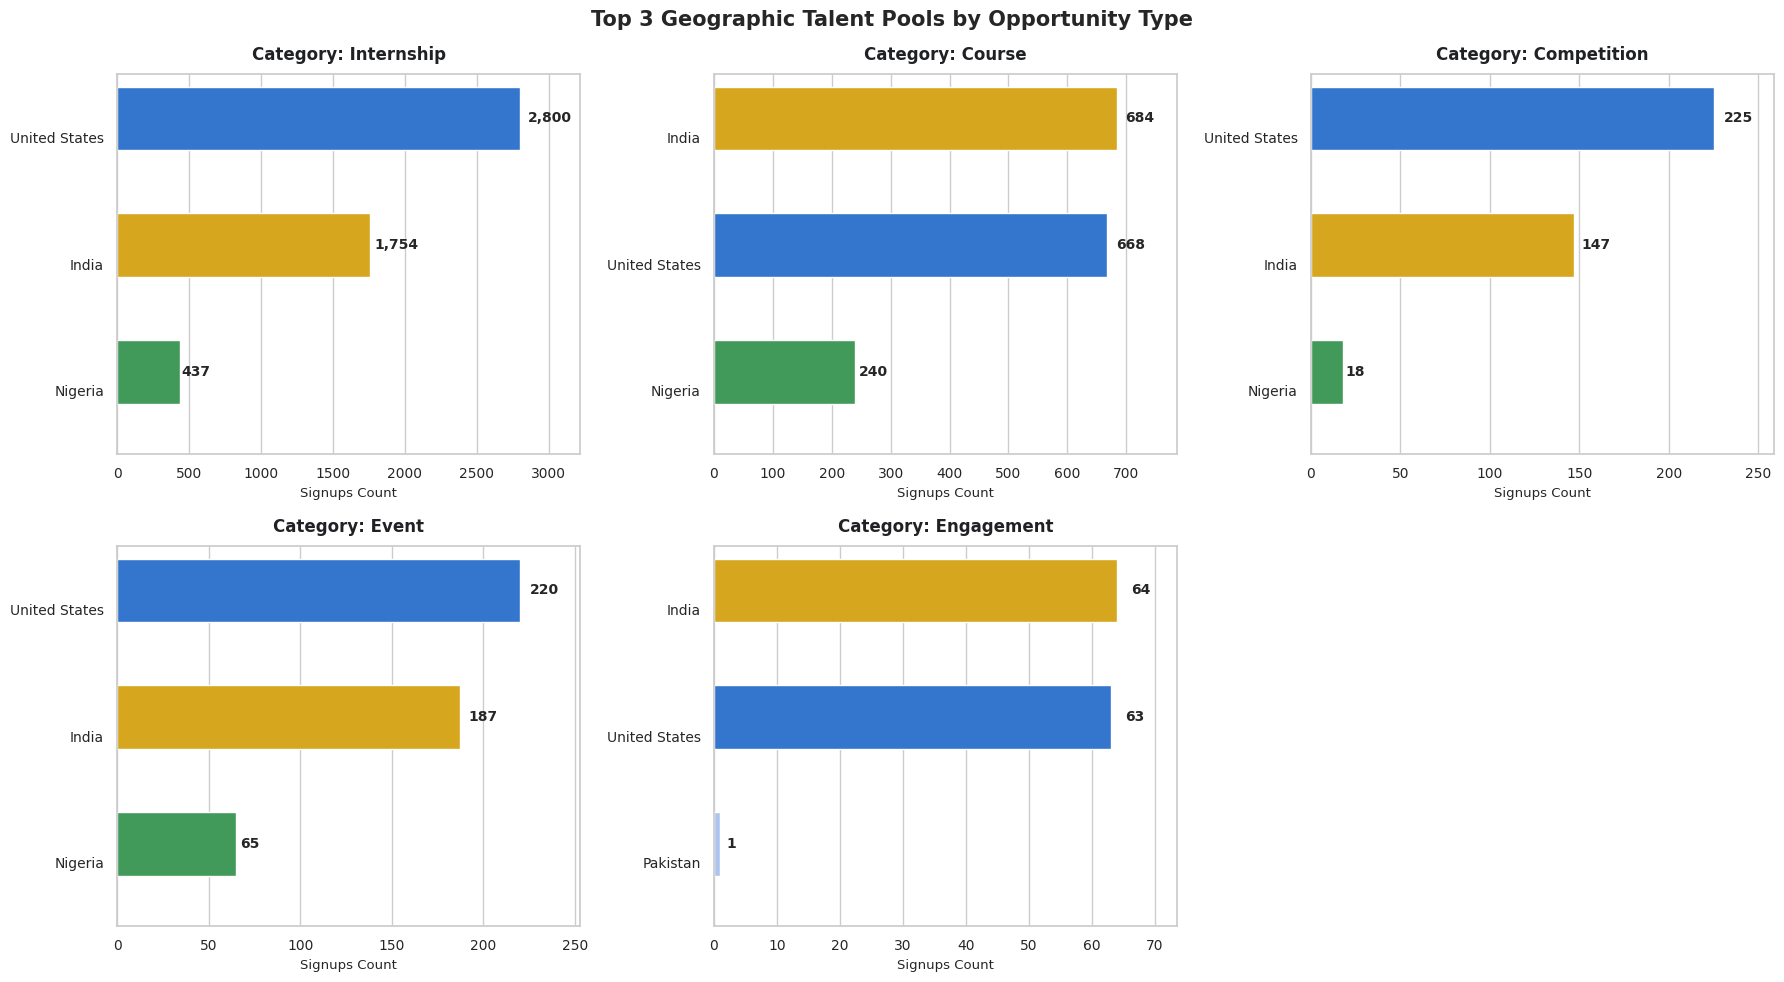

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ----------------------------------------------------
# Data Preparation from your analysis outputs
# ----------------------------------------------------
country_data = [
    # Category, Country, Count
    ['Course', 'India', 684],
    ['Course', 'United States', 668],
    ['Course', 'Nigeria', 240],

    ['Competition', 'United States', 225],
    ['Competition', 'India', 147],
    ['Competition', 'Nigeria', 18],

    ['Internship', 'United States', 2800],
    ['Internship', 'India', 1754],
    ['Internship', 'Nigeria', 437],

    ['Event', 'United States', 220],
    ['Event', 'India', 187],
    ['Event', 'Nigeria', 65],

    ['Engagement', 'India', 64],
    ['Engagement', 'United States', 63],
    ['Engagement', 'Pakistan', 1]
]

df_countries = pd.DataFrame(country_data, columns=['Category', 'Country', 'Count'])

# Set up the subplot grid (2 rows, 3 columns to match your previous layout style)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Order categories by general size/popularity
categories_order = ['Internship', 'Course', 'Competition', 'Event', 'Engagement']

# Distinct corporate color palette for countries to make tracking intuitive
country_colors = {
    'United States': '#1a73e8', # Blue
    'India': '#f4b400',          # Yellow/Orange
    'Nigeria': '#34a853',        # Green
    'Pakistan': '#a1c2fa'        # Light Blue
}

# Loop through each category to build individual localized subplots
for i, cat in enumerate(categories_order):
    ax = axes[i]
    cat_df = df_countries[df_countries['Category'] == cat].sort_values(by='Count', ascending=False)

    # Generate horizontal bars
    sns.barplot(
        data=cat_df,
        x='Count',
        y='Country',
        ax=ax,
        palette=[country_colors.get(c, '#cccccc') for c in cat_df['Country']],
        hue='Country',
        legend=False,
        height=0.5
    )

    # Add numerical labels outside the end of each bar
    for patch in ax.patches:
        width = patch.get_width()
        if width > 0:
            ax.text(
                width + (width * 0.02 + 1), # Scaled offset so labels fit nicely
                patch.get_y() + patch.get_height()/2,
                f"{int(width):,}",
                va='center', ha='left', fontsize=10, fontweight='bold'
            )

    # Subplot styling
    ax.set_title(f'Category: {cat}', fontsize=12, fontweight='bold', color='#202124', pad=10)
    ax.set_xlabel('Signups Count', fontsize=9.5)
    ax.set_ylabel('')
    ax.tick_params(labelsize=10)
    # Give x-axis dynamic padding so the numbers don't get clipped
    ax.set_xlim(0, max(cat_df['Count']) * 1.15)

# Drop the extra 6th grid slot
fig.delaxes(axes[5])

plt.suptitle('Top 3 Geographic Talent Pools by Opportunity Type', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

### Interpretation
#### Top Countries by Opportunity Category

* **Courses:** Most learners came from **India (684)**, followed closely by the **United States (668)**, while **Nigeria (240)** ranked third.
* **Competitions:** The **United States (225)** had the highest number of participants, followed by **India (147)** and **Nigeria (18)**.
* **Internships:** The **United States (2,800)** contributed the most applicants, followed by **India (1,754)** and **Nigeria (437)**.
* **Events:** Most participants were from the **United States (220)** and **India (187)**, with **Nigeria (65)** in third place.
* **Engagement:** **India (64)** and the **United States (63)** had almost the same number of participants, while **Pakistan (1)** had a very small representation.

### Summary

Overall, the **United States and India were the main sources of learners** across all opportunity categories. The **United States led participation in internships, competitions, and events**, while **India had the highest participation in courses and engagement activities**. **Nigeria** consistently ranked among the top three countries in most categories, indicating a noticeable level of learner participation from that region.


In [39]:
# Show the top 3 majors enrolling in each category
print("--- Top 3 Majors per Opportunity Category ---")
for category in df['Opportunity Category'].unique():
    print(f"\nCategory: {category}")
    top_majors = df[df['Opportunity Category'] == category]['Current/Intended Major'].value_counts().head(3)
    print(top_majors)

# Show the top 3 universities contributing to each category
print("\n--- Top 3 Institutions per Opportunity Category ---")
for category in df['Opportunity Category'].unique():
    print(f"\nCategory: {category}")
    top_institutions = df[df['Opportunity Category'] == category]['Institution Name'].value_counts().head(3)
    print(top_institutions)

--- Top 3 Majors per Opportunity Category ---

Category: Course
Current/Intended Major
Information Systems    269
Computer Science       259
Cyber Security          72
Name: count, dtype: int64

Category: Competition
Current/Intended Major
Information Systems    129
Computer Science        81
Cyber Security          21
Name: count, dtype: int64

Category: Internship
Current/Intended Major
Information Systems    1594
Computer Science        606
Health Data Science     284
Name: count, dtype: int64

Category: Event
Current/Intended Major
Information Systems    122
Computer Science        77
Cyber Security          27
Name: count, dtype: int64

Category: Engagement
Current/Intended Major
Information Systems    44
Computer Science       29
Cyber Security          8
Name: count, dtype: int64

--- Top 3 Institutions per Opportunity Category ---

Category: Course
Institution Name
Saint Louis University                                748
Illinois Institute Of Technology                       6

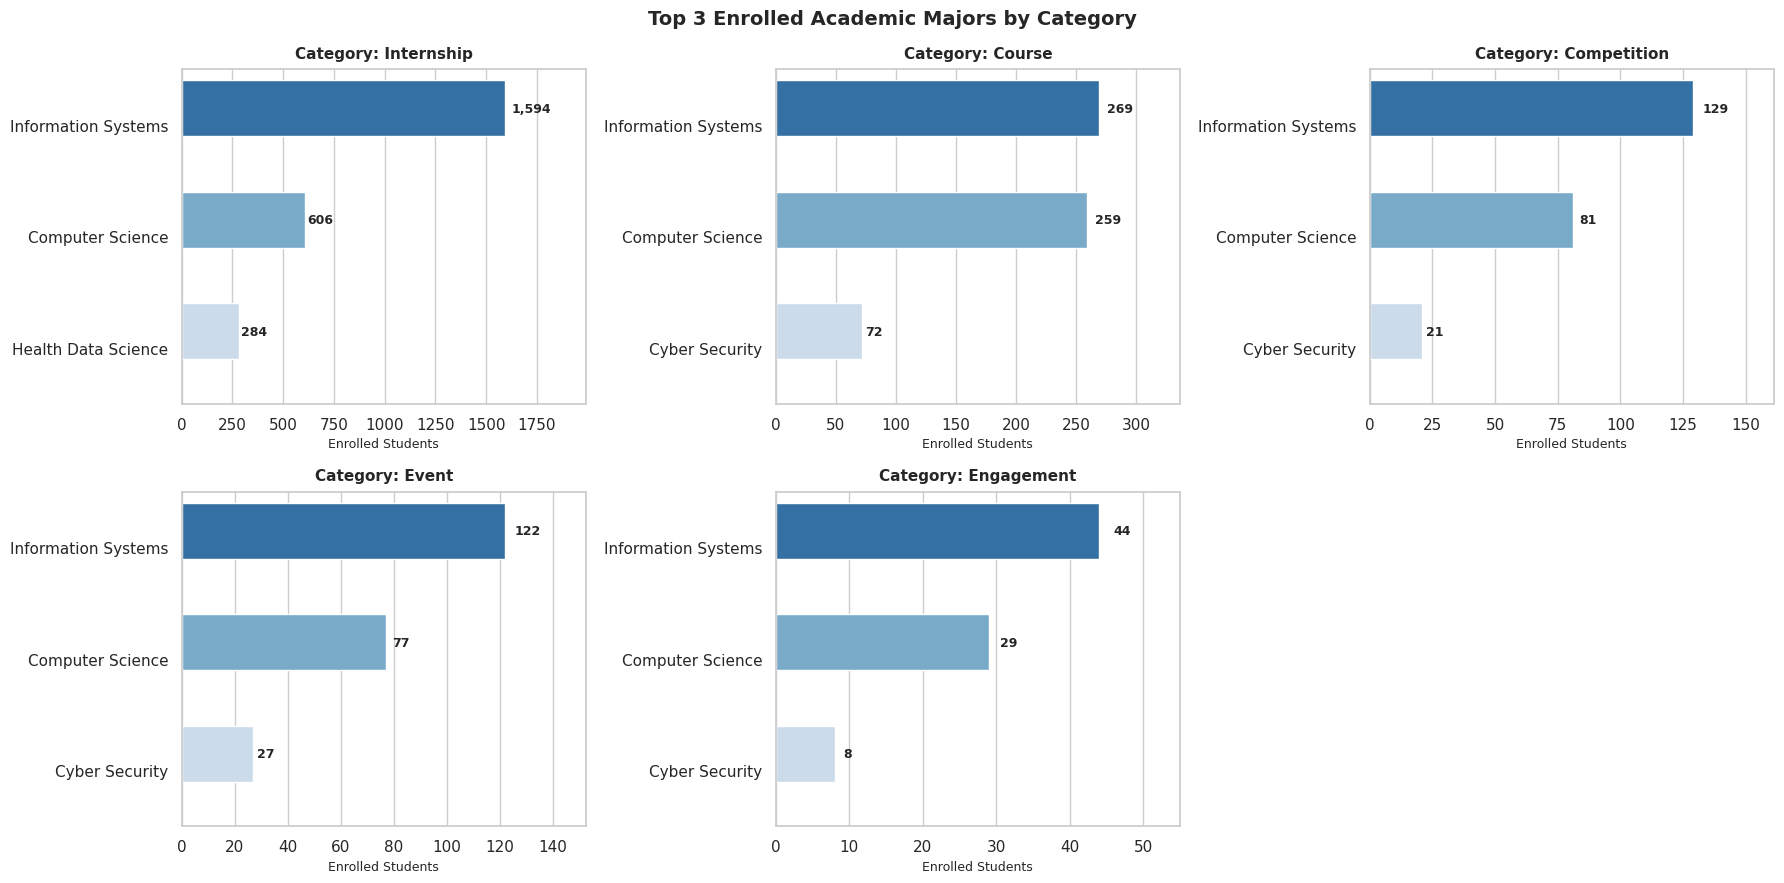

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ----------------------------------------------------
# Data Preparation from your analysis outputs
# ----------------------------------------------------
majors_data = [
    ['Course', 'Information Systems', 269], ['Course', 'Computer Science', 259], ['Course', 'Cyber Security', 72],
    ['Competition', 'Information Systems', 129], ['Competition', 'Computer Science', 81], ['Competition', 'Cyber Security', 21],
    ['Internship', 'Information Systems', 1594], ['Internship', 'Computer Science', 606], ['Internship', 'Health Data Science', 284],
    ['Event', 'Information Systems', 122], ['Event', 'Computer Science', 77], ['Event', 'Cyber Security', 27],
    ['Engagement', 'Information Systems', 44], ['Engagement', 'Computer Science', 29], ['Engagement', 'Cyber Security', 8]
]
df_majors = pd.DataFrame(majors_data, columns=['Category', 'Major', 'Count'])

inst_data = [
    ['Course', 'Saint Louis University', 748], ['Course', 'Illinois Inst. of Tech', 64], ['Course', 'KNUST', 15],
    ['Competition', 'Saint Louis University', 277], ['Competition', 'Gitam University', 4], ['Competition', 'MVSR Eng. College', 3],
    ['Internship', 'Saint Louis University', 3106], ['Internship', 'Illinois Inst. of Tech', 81], ['Internship', 'Webster University', 63],
    ['Event', 'Saint Louis University', 274], ['Event', 'Illinois Inst. of Tech', 6], ['Event', 'Vishnu Inst. of Tech', 5],
    ['Engagement', 'Saint Louis University', 82], ['Engagement', 'Vishnu Inst. of Tech', 4], ['Engagement', 'Creighton University', 2]
]
df_inst = pd.DataFrame(inst_data, columns=['Category', 'Institution', 'Count'])

# Order categories logically by size
categories_order = ['Internship', 'Course', 'Competition', 'Event', 'Engagement']

# ----------------------------------------------------
# PLOT 1: Top Majors Dashboard
# ----------------------------------------------------
fig1, axes1 = plt.subplots(2, 3, figsize=(18, 9))
axes1 = axes1.flatten()

for i, cat in enumerate(categories_order):
    ax = axes1[i]
    cat_df = df_majors[df_majors['Category'] == cat].sort_values(by='Count', ascending=False)

    sns.barplot(data=cat_df, x='Count', y='Major', ax=ax, palette='Blues_r', hue='Major', legend=False, height=0.5)

    for patch in ax.patches:
        width = patch.get_width()
        if width > 0:
            ax.text(width + (width*0.02 + 1), patch.get_y() + patch.get_height()/2, f"{int(width):,}", va='center', ha='left', fontsize=9, fontweight='bold')

    ax.set_title(f'Category: {cat}', fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Enrolled Students', fontsize=9)
    ax.set_ylabel('')
    ax.set_xlim(0, max(cat_df['Count']) * 1.25)

fig1.delaxes(axes1[5])
plt.suptitle('Top 3 Enrolled Academic Majors by Category', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()



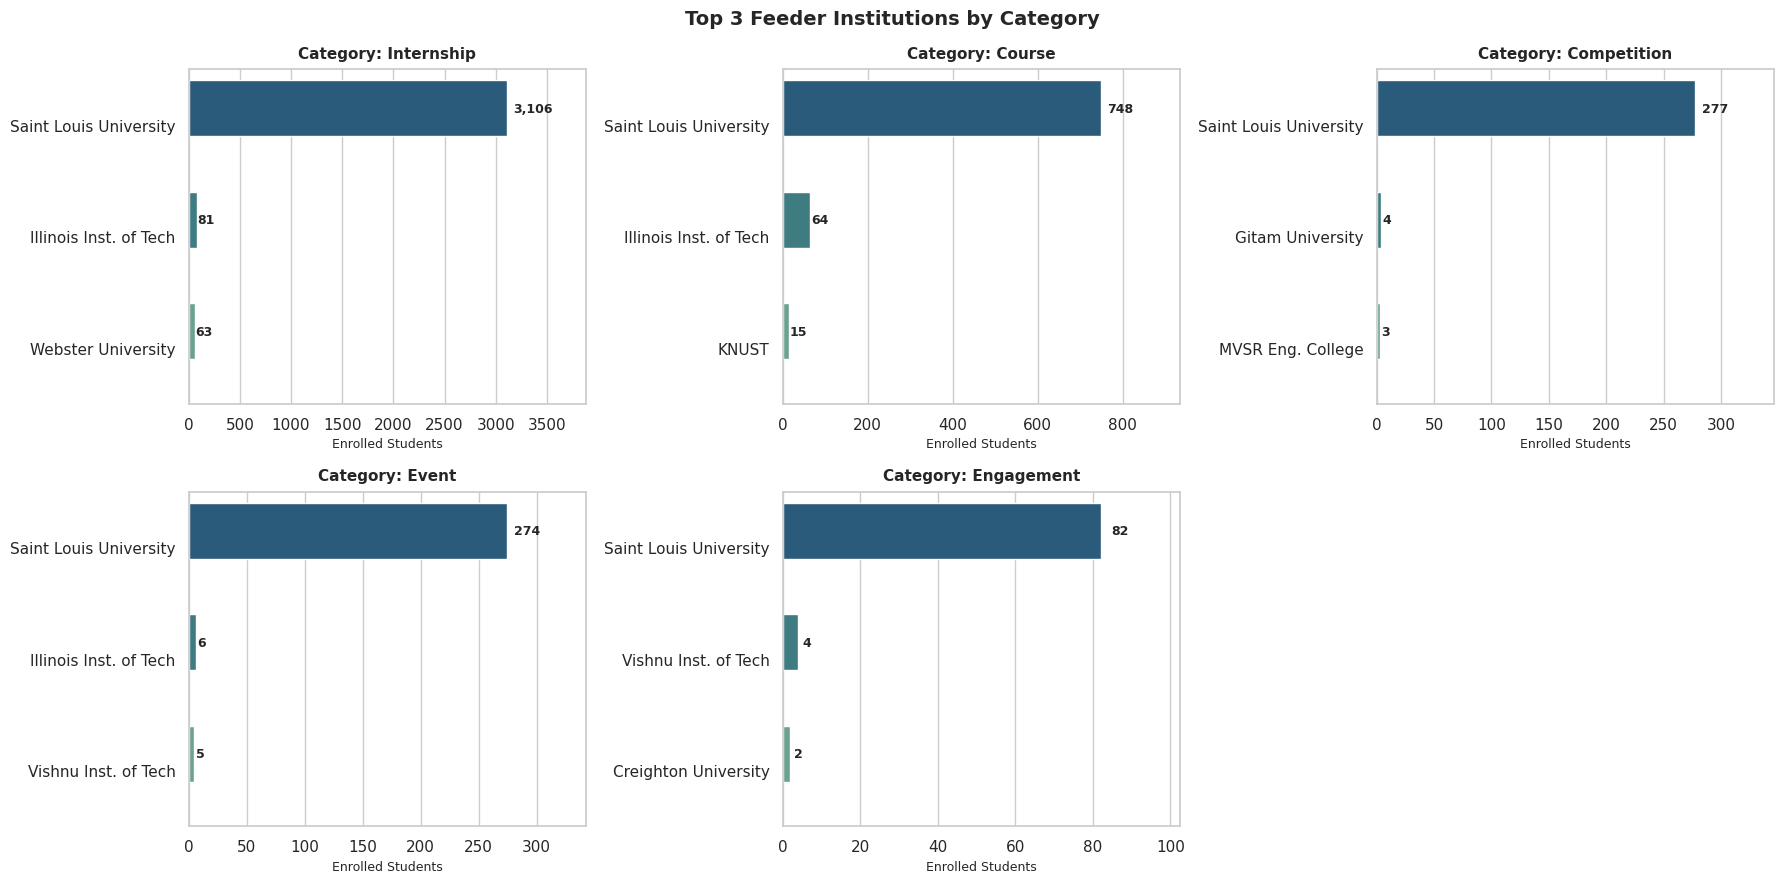

In [59]:
# ----------------------------------------------------
# PLOT 2: Top Institutions Dashboard
# ----------------------------------------------------
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 9))
axes2 = axes2.flatten()

for i, cat in enumerate(categories_order):
    ax = axes2[i]
    cat_df = df_inst[df_inst['Category'] == cat].sort_values(by='Count', ascending=False)

    # Using 'crest_r' or 'mako_r' for a beautiful teal/dark corporate vibe
    sns.barplot(data=cat_df, x='Count', y='Institution', ax=ax, palette='crest_r', hue='Institution', legend=False, height=0.5)

    for patch in ax.patches:
        width = patch.get_width()
        if width > 0:
            ax.text(width + (width*0.02 + 1), patch.get_y() + patch.get_height()/2, f"{int(width):,}", va='center', ha='left', fontsize=9, fontweight='bold')

    ax.set_title(f'Category: {cat}', fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Enrolled Students', fontsize=9)
    ax.set_ylabel('')
    ax.set_xlim(0, max(cat_df['Count']) * 1.25)

fig2.delaxes(axes2[5])
plt.suptitle('Top 3 Feeder Institutions by Category', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()

plt.show()

### Interpretation

#### Top Majors by Opportunity Category

* **Information Systems** was the most common major across **all opportunity categories**.
* **Computer Science** consistently ranked second in every category.
* The third most common major varied:

  * **Cyber Security** was third for **Courses, Competitions, Events, and Engagements**.
  * **Health Data Science** was third for **Internships**.

#### Top Institutions by Opportunity Category

* **Saint Louis University** contributed the highest number of learners in **every opportunity category**, by a large margin.
* **Illinois Institute of Technology** was the second-largest contributor for **Courses, Internships, and Events**.
* Other institutions, such as **Kwame Nkrumah University of Science and Technology**, **Webster University**, **Gitam University**, and **Vishnu Institute of Technology**, contributed smaller numbers of learners depending on the category.

### Summary

Overall, **Information Systems and Computer Science students were the most active participants** across all opportunity categories. **Saint Louis University** was the dominant source of learners, contributing far more participants than any other institution. This suggests that both the learner base and institutional participation were concentrated around a few key majors and one major university.


# Operational Behaviors Sub-Category

In [40]:
df['SignUp Month'] = pd.to_datetime(df['Learner SignUp DateTime']).dt.strftime('%Y-%m')
# Convert the numeric month strings into clean, readable Month Names (e.g., June 2023)
df['SignUp Month Name'] = pd.to_datetime(df['SignUp Month']).dt.strftime('%B %Y')

# Calculate lag between signup and application in days
df['SignUp to Apply Lag (days)'] = (pd.to_datetime(df['Apply Date']) - pd.to_datetime(df['Learner SignUp DateTime'])).dt.days

# Part 1: Median days calculation
print("--- Median Days from Signup to Application ---")
median_lag = df.groupby('Opportunity Category')['SignUp to Apply Lag (days)'].median()
for category, days in median_lag.items():
    print(f"  - {category}: {days:.1f} days")

# Part 2: Clean Peak Months calculation
print("\n--- Top 2 Peak Signup Months per Category ---")
for category in df['Opportunity Category'].unique():
    print(f"\n Category: {category}")

    # Get the top 2 months using our new readable month name column
    top_months = df[df['Opportunity Category'] == category]['SignUp Month Name'].value_counts().head(2)

    for month, count in top_months.items():
        print(f"  - {month}: {count} signups")

--- Median Days from Signup to Application ---
  - Competition: 55.0 days
  - Course: 1.0 days
  - Engagement: 89.0 days
  - Event: 34.0 days
  - Internship: 2.0 days

--- Top 2 Peak Signup Months per Category ---

 Category: Course
  - June 2023: 386 signups
  - July 2023: 210 signups

 Category: Competition
  - February 2024: 91 signups
  - August 2023: 50 signups

 Category: Internship
  - January 2024: 1299 signups
  - August 2023: 767 signups

 Category: Event
  - February 2024: 101 signups
  - January 2024: 69 signups

 Category: Engagement
  - June 2023: 26 signups
  - August 2023: 20 signups


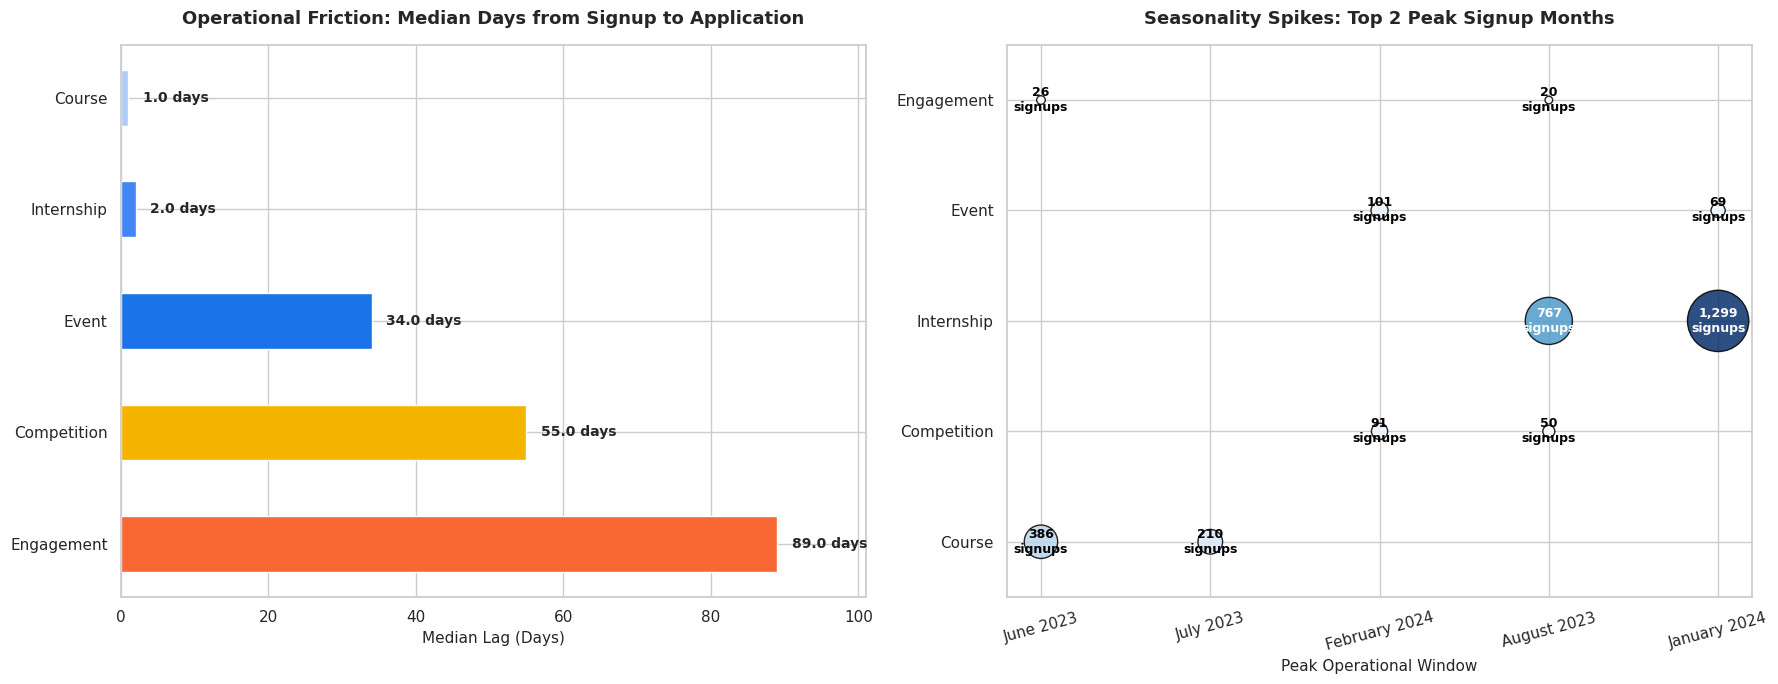

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ----------------------------------------------------
# Data Preparation from your analysis outputs
# ----------------------------------------------------
lag_data = {
    'Category': ['Competition', 'Course', 'Engagement', 'Event', 'Internship'],
    'Median Days': [55.0, 1.0, 89.0, 34.0, 2.0]
}
df_lag = pd.DataFrame(lag_data).sort_values(by='Median Days', ascending=False)

peak_data = [
    ['Course', 'June 2023', 386], ['Course', 'July 2023', 210],
    ['Competition', 'February 2024', 91], ['Competition', 'August 2023', 50],
    ['Internship', 'January 2024', 1299], ['Internship', 'August 2023', 767],
    ['Event', 'February 2024', 101], ['Event', 'January 2024', 69],
    ['Engagement', 'June 2023', 26], ['Engagement', 'August 2023', 20]
]
df_peaks = pd.DataFrame(peak_data, columns=['Category', 'Month', 'Signups'])

# Initialize the subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.set_theme(style="whitegrid")

# ----------------------------------------------------
# PLOT 1: Operational Lag (Horizontal Bar Chart)
# ----------------------------------------------------
# Custom palette prioritizing the longest wait categories
lag_palette = ['#f86734', '#f4b400', '#1a73e8', '#4285f4', '#aecbfa']

bars = axes[0].barh(df_lag['Category'], df_lag['Median Days'], color=lag_palette, height=0.5)

# Add clear data labels to the ends of the bars
for bar in bars:
    width = bar.get_width()
    axes[0].text(
        width + 2,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f} days",
        va='center', ha='left', fontsize=10, fontweight='bold'
    )

axes[0].set_title('Operational Friction: Median Days from Signup to Application', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Median Lag (Days)', fontsize=11)
axes[0].set_xlim(0, max(df_lag['Median Days']) + 12)

# ----------------------------------------------------
# PLOT 2: Peak Campaign Months (Bubble/Scatter Plot Matrix)
# ----------------------------------------------------
# Mapping categorical order for alignment consistency
cat_order = ['Engagement', 'Course', 'Event', 'Competition', 'Internship']

# Scatter plot representing the seasonal peaks
scatter = axes[1].scatter(
    data=df_peaks,
    x='Month',
    y='Category',
    s=df_peaks['Signups'] * 1.5, # Scale size for visualization contrast
    c='Signups',
    cmap='Blues',
    edgecolors='black',
    linewidth=1,
    alpha=0.85
)

# Add text labels displaying the signup counts directly over or next to the markers
for _, row in df_peaks.iterrows():
    axes[1].text(
        x=row['Month'],
        y=row['Category'],
        s=f"{row['Signups']:,}\nsignups",
        ha='center', va='center',
        fontsize=9, fontweight='bold',
        color='black' if row['Signups'] < 600 else 'white'
    )

axes[1].set_title('Seasonality Spikes: Top 2 Peak Signup Months', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Peak Operational Window', fontsize=11)
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=15)
axes[1].set_ylim(-0.5, len(cat_order) - 0.5)

# Global layout polish
plt.tight_layout()
plt.show()

### Interpretation

#### Median Days from Signup to Application

* **Courses** had the shortest application time, with learners applying **within 1 day** of signing up.
* **Internships** also had a very short application time, with a median of **2 days**.
* **Events** took longer, with learners applying after a median of **34 days**.
* **Competitions** had a median application time of **55 days**.
* **Engagement** activities had the longest delay, with learners applying after a median of **89 days**.

#### Peak Signup Months by Category

* **Courses:** The highest signup activity occurred in **June 2023 (386 signups)**, followed by **July 2023 (210 signups)**.
* **Competitions:** The busiest months were **February 2024 (91 signups)** and **August 2023 (50 signups)**.
* **Internships:** Signups peaked in **January 2024 (1,299 signups)**, with **August 2023 (767 signups)** as the second-highest month.
* **Events:** The most signups were recorded in **February 2024 (101 signups)**, followed by **January 2024 (69 signups)**.
* **Engagement:** The highest signup activity was in **June 2023 (26 signups)**, followed by **August 2023 (20 signups)**.

### Summary

Overall, learners **applied almost immediately for courses and internships**, while they took considerably longer to apply for **events, competitions, and engagement activities**. Peak signup periods also differed by opportunity type, with **June 2023** being the busiest month for courses and engagement, **January 2024** for internships, and **February 2024** for competitions and events. This indicates that learner interest varies across opportunity categories and time periods.


## AI-Assisted Analysis

### AI Tools Used

* **Google Gemini (Advanced Data Analysis):** Used to generate and improve Python code, simplify code outputs, and support data analysis.
* **ChatGPT:** Used to explain the analysis results, write simple interpretations, and improve the wording of findings for the report.

### Prompts Used

* Requested suggestions to improve anaysis presentation and visualizations.
* Asked for simple Python code that could be run in Google Colab.
* Requested code improvements to make the outputs easier to understand.
* Simplify interpretations of the results in report-friendly language.

### Key Insights

* **Internships** received the highest number of signups but also had the highest rejection rate.
* **Courses, Events, Competitions, and Engagement** opportunities showed high learner participation, with most learners reaching the **Team Allocated** stage.
* Peak signup months were identified for each opportunity category, showing when learner interest was highest.
* The analysis also helped identify data quality issues and made the results easier to understand.

### Validation

* All AI-generated Python code was executed in **Google Colab**.
* The outputs were manually checked against the dataset to verify that the values and percentages were correct.
* The final interpretations were reviewed to ensure they accurately reflected the analysis results.
